# AllLife Bank — Credit Card Customer Segmentation

Welcome to the project on Unsupervised Learning. We will be using Credit Card Customer Data for this project.

## Context

AllLife Bank wants to focus on its credit card customer base in the next financial year. They have been advised by their marketing research team, that the penetration in the market can be improved. Based on this input, the marketing team proposes to run personalized campaigns to target new customers as well as upsell to existing customers.

Another insight from the market research was that the customers perceive the support services of the bank poorly. Based on this, the operations team wants to upgrade the service delivery model, to ensure that customers' queries are resolved faster. The head of marketing and the head of delivery, both decide to reach out to the Data Science team for help.

## Objective

Identify different segments in the existing customer base, taking into account their spending patterns as well as past interactions with the bank.

## Data Dictionary

Data is available on customers of the bank with their credit limit, the total number of credit cards the customer has, and different channels through which the customer has contacted the bank for any queries. These different channels include visiting the bank, online, and through a call center.

- Sl_no - Customer Serial Number

- Customer Key - Customer identification

- Avg_Credit_Limit	- Average credit limit (currency is not specified, you can make an assumption around this)

- Total_Credit_Cards - Total number of credit cards

- Total_visits_bank	- Total bank visits

- Total_visits_online - Total online visits

- Total_calls_made - Total calls made

## Setup and Data Overview

Note: Please make sure you have installed the sklearn_extra library before running the below cell. If you have not installed the library, please run the below code to install the library:

In [ ]:
# scikit-learn-extra is optional. A fallback K-Medoids implementation is included later if it is not installed.

Note: After running this commands, you’ll be prompted to restart your notebook/runtime. Please go ahead and do that. Once restarted, simply proceed to the next step of your workflow

In [ ]:
# The notebook uses the environment's installed NumPy version.

### Loading the data

In [ ]:
# Import libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

# Make plots easier to read
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

# Load the data
data_path = "/mnt/data/Credit Card Customer Data.xlsx"
df = pd.read_excel(data_path)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (660, 7)


### Data Overview

- Observations

- Sanity checks

In [ ]:
# Basic data overview
print("Rows and columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isnull().sum().to_frame("missing_count"))

print("\nDuplicate customer keys:", df["Customer Key"].duplicated().sum())
print("Duplicate full rows:", df.duplicated().sum())

display(df.describe().T)

Rows and columns: (660, 7)

Column names:
['Sl_No', 'Customer Key', 'Avg_Credit_Limit', 'Total_Credit_Cards', 'Total_visits_bank', 'Total_visits_online', 'Total_calls_made']

Data types:



Missing values:



Duplicate customer keys: 5
Duplicate full rows: 0


## Data Preprocessing and Exploratory Data Analysis

- EDA is an important part of any project involving data.

- It is important to investigate and understand the data better before building a model with it.

- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.

- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

- Check and drop the duplicate customer keys

- Drop the variables that are not required for the analysis

- Check duplicate rows and remove them.

Questions:

- How does the distribution and outliers look for each variable in the data?

- How are the variables correlated with each other?

### Summary Statistics

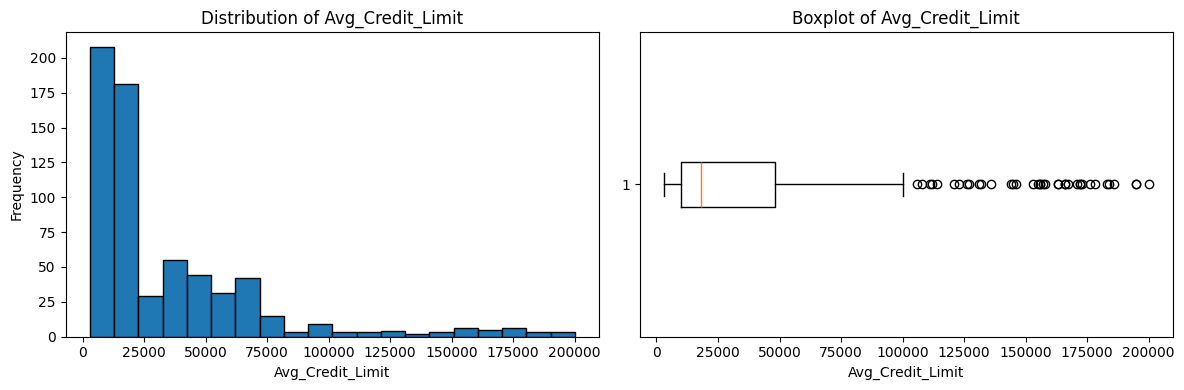

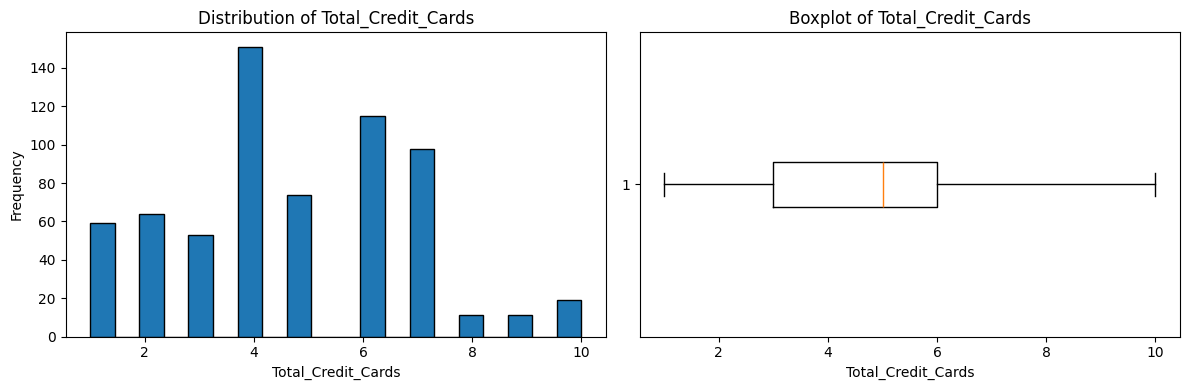

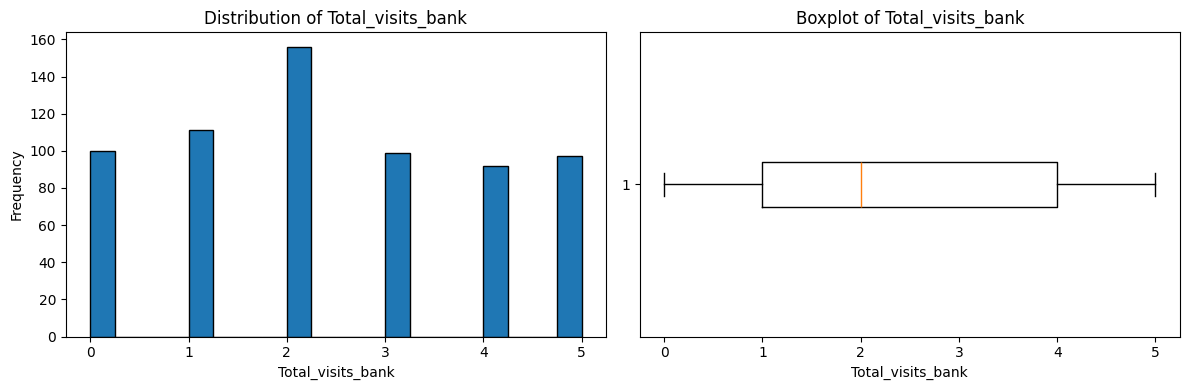

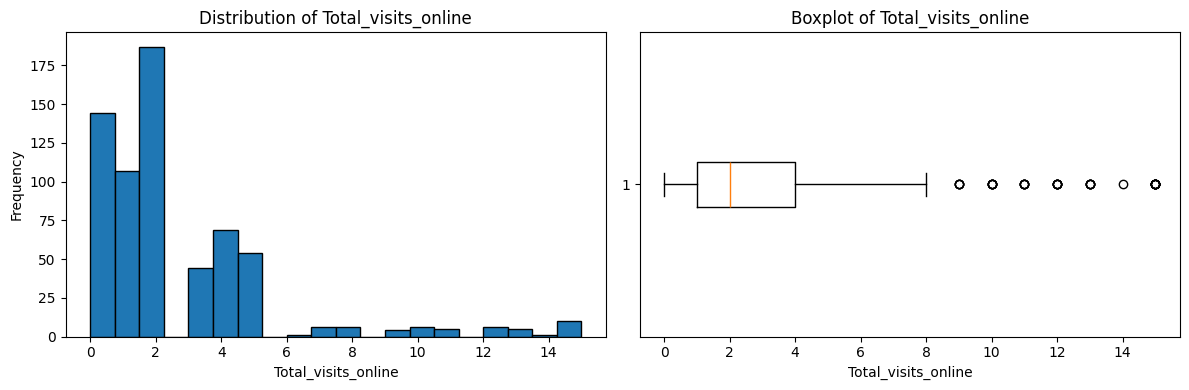

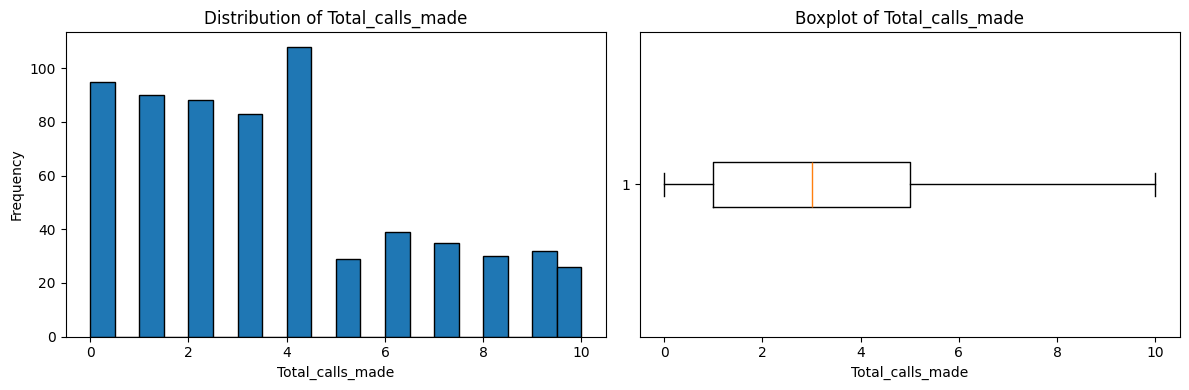

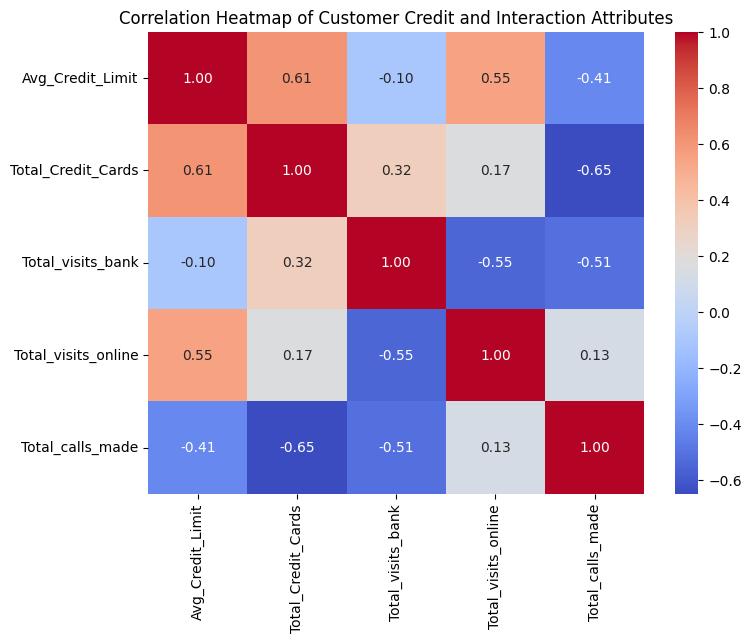

Duplicate customer-key records:


Shape after dropping duplicate customer keys: (655, 7)

Summary statistics for modeling variables:


In [ ]:
# Check and remove duplicate customer keys as requested in the notebook instructions
df_clean = df.copy()

duplicate_keys = df_clean[df_clean["Customer Key"].duplicated(keep=False)].sort_values("Customer Key")
print("Duplicate customer-key records:")
display(duplicate_keys)

df_clean = df_clean.drop_duplicates(subset="Customer Key", keep="first").reset_index(drop=True)
print("Shape after dropping duplicate customer keys:", df_clean.shape)

# Drop identifier columns that are not useful for clustering
cluster_df = df_clean.drop(columns=["Sl_No", "Customer Key"])

print("\nSummary statistics for modeling variables:")
display(cluster_df.describe().T)

# Distribution and outlier checks
for col in cluster_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(cluster_df[col], bins=20, edgecolor="black")
    axes[0].set_title(f"Distribution of {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frequency")
    axes[1].boxplot(cluster_df[col], vert=False)
    axes[1].set_title(f"Boxplot of {col}")
    axes[1].set_xlabel(col)
    plt.tight_layout()
    plt.show()

# Correlation heatmap
corr = cluster_df.corr()
display(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Customer Credit and Interaction Attributes")
plt.show()

Observations:

- The data contains 660 records and 7 columns. There are no missing values.

- Five duplicate customer keys were found. Following the notebook instruction, the duplicate customer keys were removed before modeling.

- The identifier fields Sl_No and Customer Key were dropped because they do not describe customer behavior.

- Avg_Credit_Limit is right-skewed and contains high-value outliers. This is expected because a small group of premium customers has very high credit limits.

- Total_visits_online also has high values for a smaller digital-heavy customer group.

- Avg_Credit_Limit is positively correlated with Total_Credit_Cards and Total_visits_online.

- Total_calls_made is negatively correlated with Avg_Credit_Limit and Total_Credit_Cards, which suggests that high-call customers tend to be lower-value customers.

### Scaling the Data

In [ ]:
# Scale the modeling variables
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_df)

scaled_df = pd.DataFrame(scaled_data, columns=cluster_df.columns)
display(scaled_df.head())

### Dimensionality Reduction with PCA

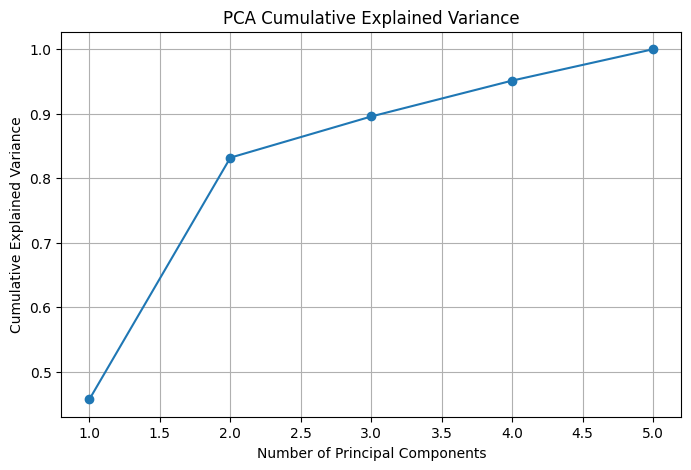

Number of components selected: 3


In [ ]:
# Apply PCA to the scaled data
pca = PCA(random_state=42)
pca_data = pca.fit_transform(scaled_df)

explained_variance = pd.DataFrame({
    "Component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Explained Variance Ratio": pca.explained_variance_ratio_,
    "Cumulative Explained Variance": np.cumsum(pca.explained_variance_ratio_)
})
display(explained_variance)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.grid(True)
plt.show()

# Use enough components to explain at least 85% of the variance
n_components = int(np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.85) + 1)
print("Number of components selected:", n_components)

pca_final = PCA(n_components=n_components, random_state=42)
pca_components = pca_final.fit_transform(scaled_df)
pca_df = pd.DataFrame(pca_components, columns=[f"PC{i+1}" for i in range(n_components)])
display(pca_df.head())

## K-Means

Let us now fit the K-means algorithm on our pca components and find out the optimum number of clusters to use.

We will do this in 3 steps:

- Initialize a dictionary to store the Sum of Squared Error (SSE) for each K

- Run for a range of Ks and store SSE for each run

- Plot the SSE vs K and plot the elbow curve

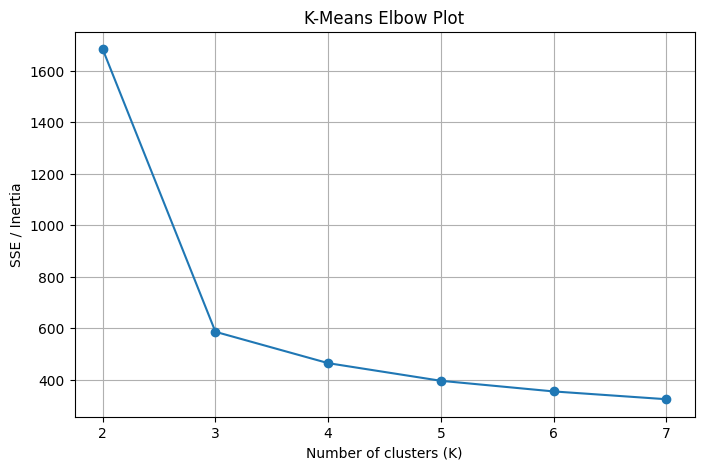

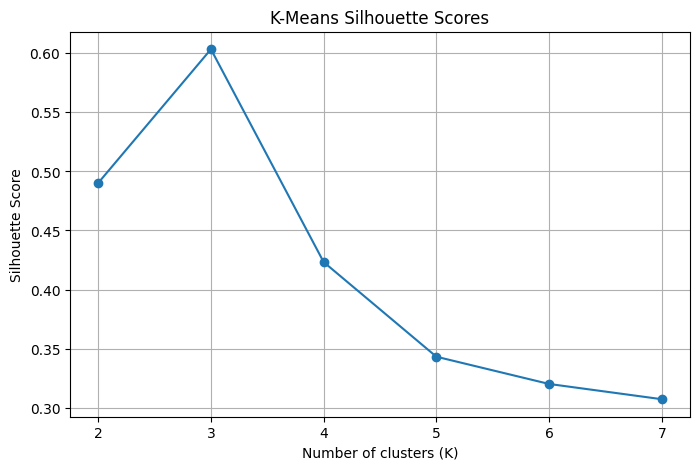

Best K by silhouette score: 3


In [ ]:
# K-Means: Elbow method and silhouette scores
sse = {}
sil_scores = {}

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(pca_df)
    sse[k] = kmeans.inertia_
    sil_scores[k] = silhouette_score(pca_df, labels)

plt.figure(figsize=(8, 5))
plt.plot(list(sse.keys()), list(sse.values()), marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("SSE / Inertia")
plt.title("K-Means Elbow Plot")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette Scores")
plt.grid(True)
plt.show()

kmeans_scores = pd.DataFrame({
    "K": list(sse.keys()),
    "SSE": list(sse.values()),
    "Silhouette Score": list(sil_scores.values())
})
display(kmeans_scores)

best_k = max(sil_scores, key=sil_scores.get)
print("Best K by silhouette score:", best_k)

- The elbow plot shows a clear improvement from 2 to 3 clusters, after which the improvement becomes smaller.

- The silhouette scores also support K = 3 as the best and most interpretable solution.

- A 3-cluster solution is also business-friendly because it separates customers into practical groups: branch-engaged core customers, premium digital customers, and low-value high-support callers.

In [ ]:
# Fit K-Means with the selected value of K
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=20)
df_clean["KMeans_Cluster"] = kmeans_final.fit_predict(pca_df)

# Rename clusters based on business profile
kmeans_profile_temp = df_clean.groupby("KMeans_Cluster")[cluster_df.columns].mean()
display(kmeans_profile_temp)

def name_segments(profile):
    names = {}
    for cluster in profile.index:
        row = profile.loc[cluster]
        if row["Avg_Credit_Limit"] == profile["Avg_Credit_Limit"].max():
            names[cluster] = "Premium Digital Power Users"
        elif row["Total_calls_made"] == profile["Total_calls_made"].max():
            names[cluster] = "Low-Value High-Support Callers"
        else:
            names[cluster] = "Branch-Engaged Core Customers"
    return names

kmeans_names = name_segments(kmeans_profile_temp)
df_clean["KMeans_Segment"] = df_clean["KMeans_Cluster"].map(kmeans_names)

print(kmeans_names)
display(df_clean.head())

{0: 'Branch-Engaged Core Customers', 1: 'Premium Digital Power Users', 2: 'Low-Value High-Support Callers'}


### Cluster Profiles

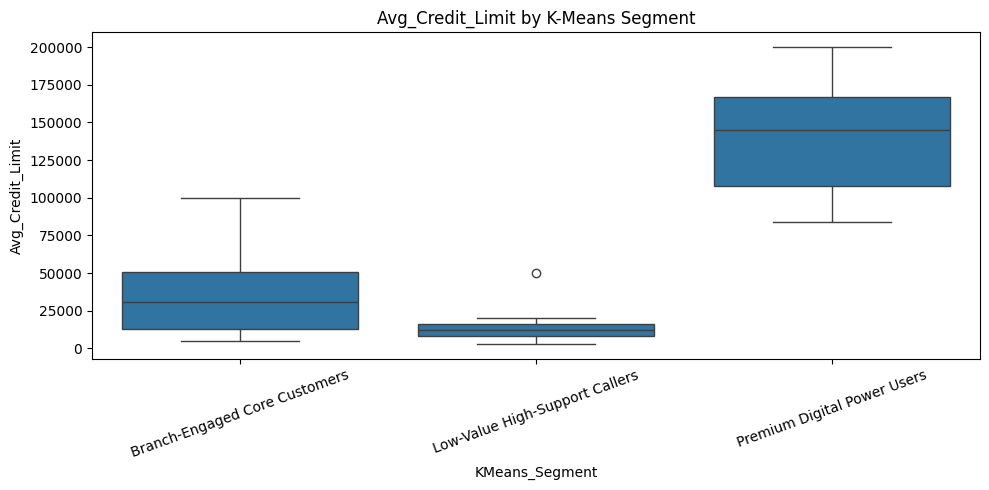

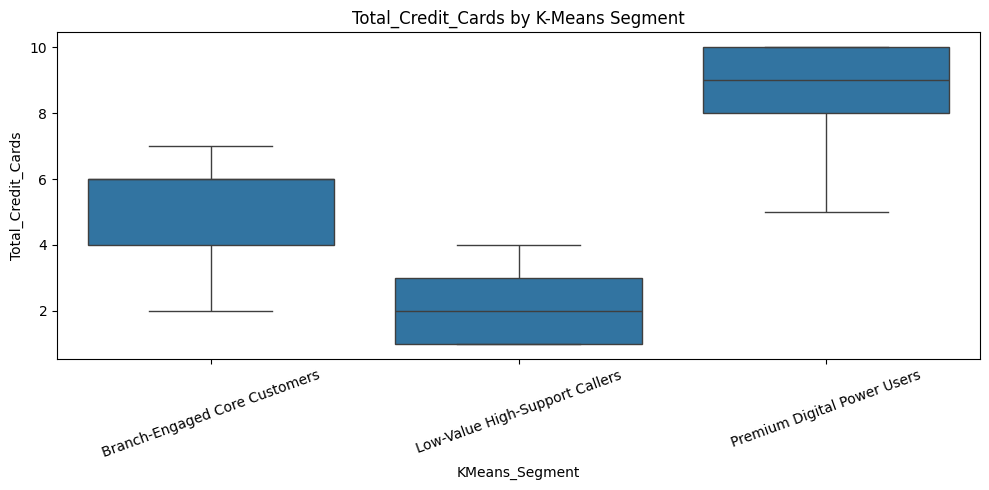

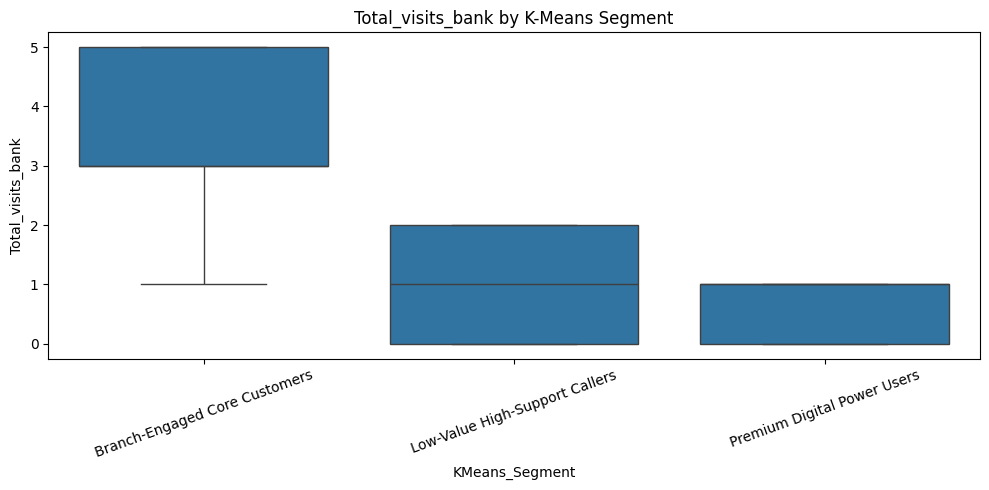

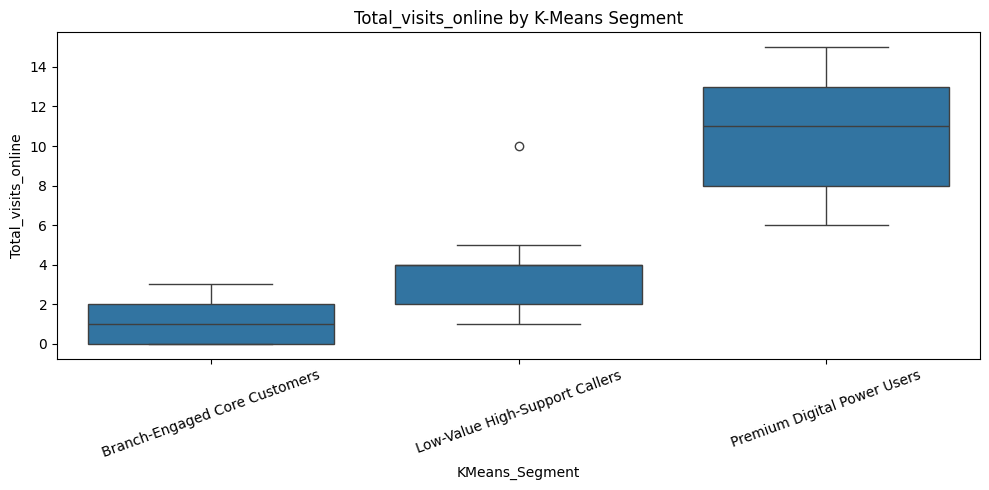

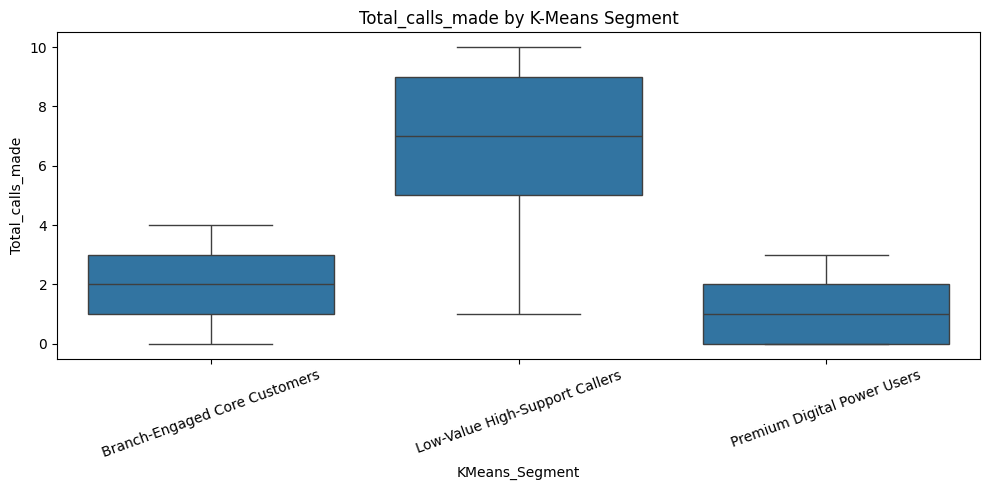

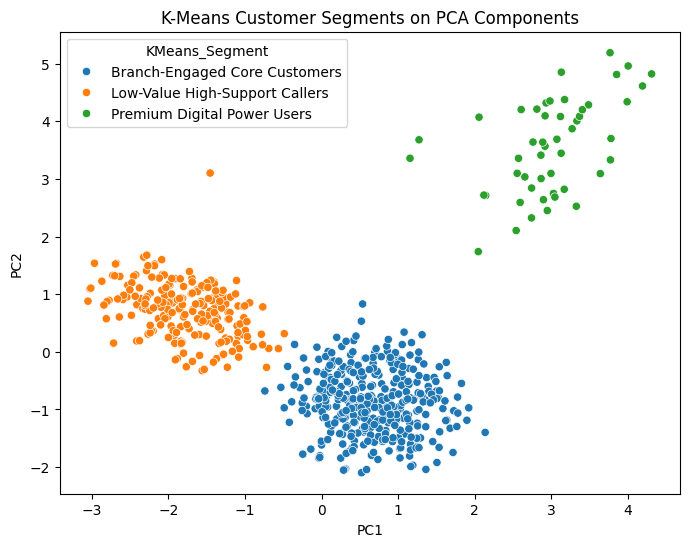

In [ ]:
def cluster_profile(data, label_col):
    profile = data.groupby(label_col)[cluster_df.columns].mean()
    counts = data[label_col].value_counts().sort_index()
    profile.insert(0, "Customer Count", counts)
    profile.insert(1, "Share", counts / len(data))
    return profile

kmeans_profile = cluster_profile(df_clean, "KMeans_Segment").sort_values("Avg_Credit_Limit")
display(kmeans_profile)

# Box plots by K-Means segment
for col in cluster_df.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df_clean, x="KMeans_Segment", y=col)
    plt.title(f"{col} by K-Means Segment")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

# PCA visualization
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pd.concat([pca_df[["PC1", "PC2"]], df_clean["KMeans_Segment"]], axis=1),
                x="PC1", y="PC2", hue="KMeans_Segment")
plt.title("K-Means Customer Segments on PCA Components")
plt.show()

Cluster Profiles:

- Premium Digital Power Users: smallest segment, but highest average credit limit, highest card ownership, and highest online visits. This group should receive premium digital offers, higher-limit products, rewards, and retention campaigns.

- Branch-Engaged Core Customers: largest customer group with moderate credit limits, several credit cards, and the highest branch visit behavior. This group is best reached through relationship-led branch campaigns and assisted cross-sell.

- Low-Value High-Support Callers: lower average credit limits, fewer cards, and the highest call-center activity. This group should receive digital education, simpler offers, proactive support, and call-deflection journeys.

## Gaussian Mixture Model

Let's now create clusters using the Gaussian Mixture Model.

- Apply the Gaussian Mixture Model algorithm on the pca components

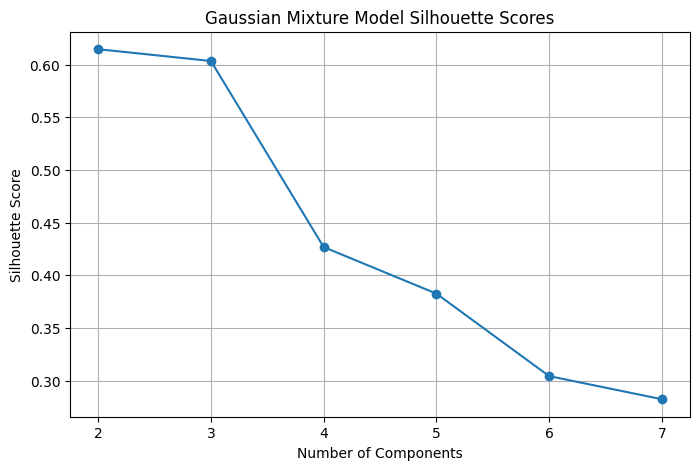

Best GMM components by silhouette score: 2


{0: 'Branch-Engaged Core Customers', 1: 'Premium Digital Power Users', 2: 'Low-Value High-Support Callers'}


In [ ]:
# Gaussian Mixture Model clustering
gmm_scores = {}

for k in range(2, 8):
    gmm = GaussianMixture(n_components=k, random_state=42, covariance_type="full")
    labels = gmm.fit_predict(pca_df)
    gmm_scores[k] = silhouette_score(pca_df, labels)

gmm_score_df = pd.DataFrame({
    "Number of Components": list(gmm_scores.keys()),
    "Silhouette Score": list(gmm_scores.values())
})
display(gmm_score_df)

plt.figure(figsize=(8, 5))
plt.plot(list(gmm_scores.keys()), list(gmm_scores.values()), marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Silhouette Score")
plt.title("Gaussian Mixture Model Silhouette Scores")
plt.grid(True)
plt.show()

best_gmm_k = max(gmm_scores, key=gmm_scores.get)
print("Best GMM components by silhouette score:", best_gmm_k)

gmm_final = GaussianMixture(n_components=3, random_state=42, covariance_type="full")
df_clean["GMM_Cluster"] = gmm_final.fit_predict(pca_df)

gmm_profile_temp = df_clean.groupby("GMM_Cluster")[cluster_df.columns].mean()
gmm_names = name_segments(gmm_profile_temp)
df_clean["GMM_Segment"] = df_clean["GMM_Cluster"].map(gmm_names)

display(gmm_profile_temp)
print(gmm_names)

### Cluster Profiles

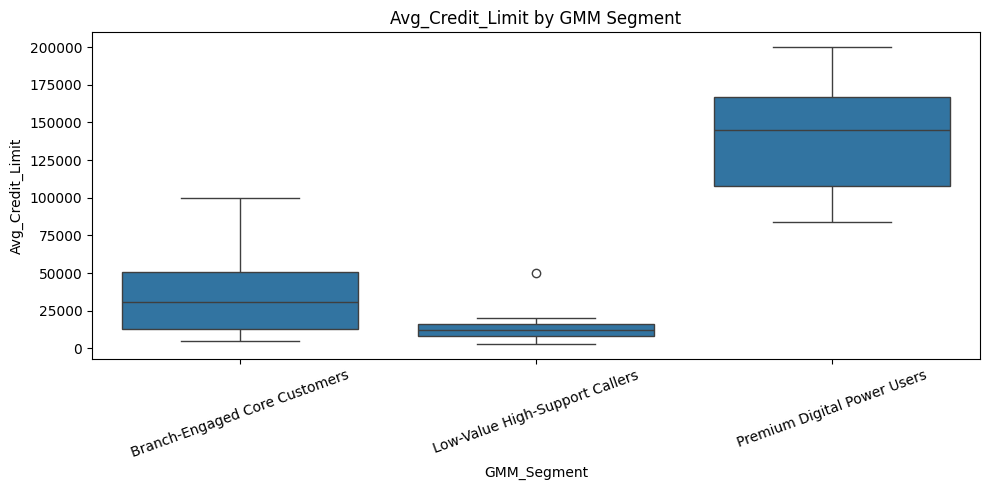

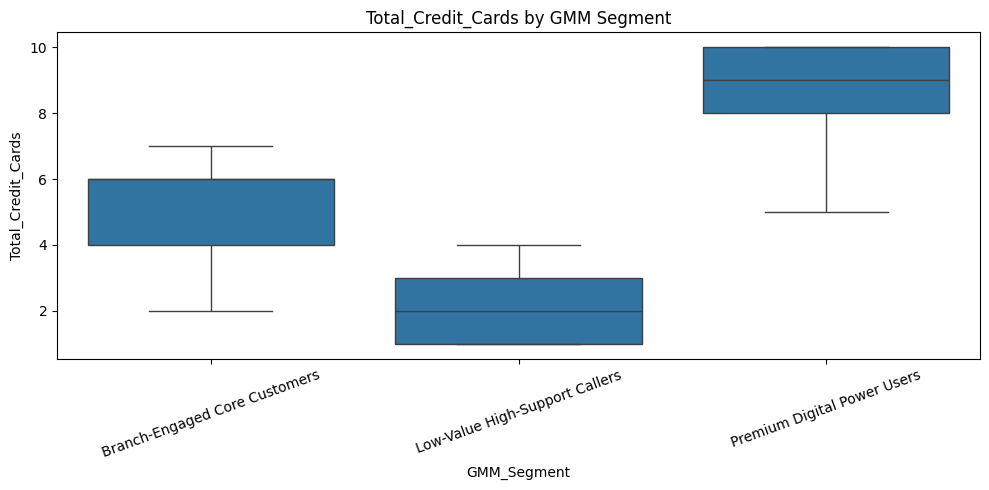

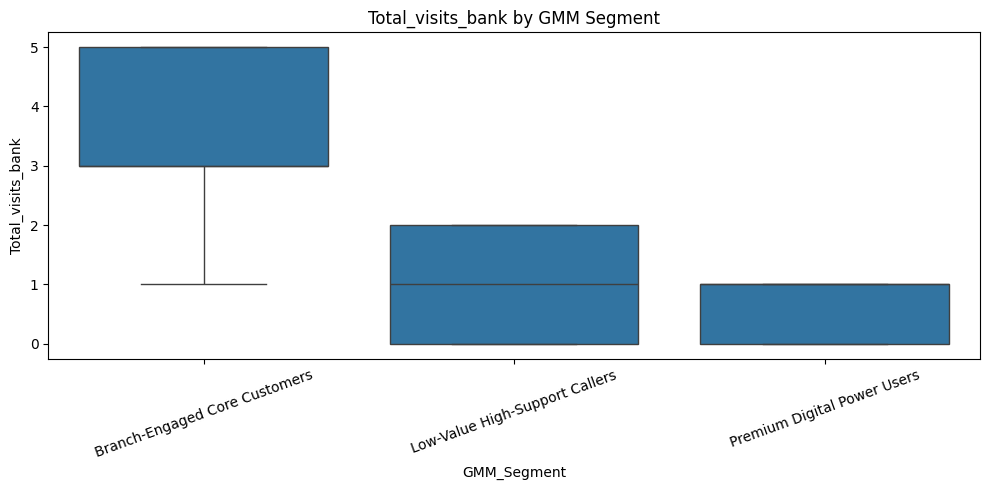

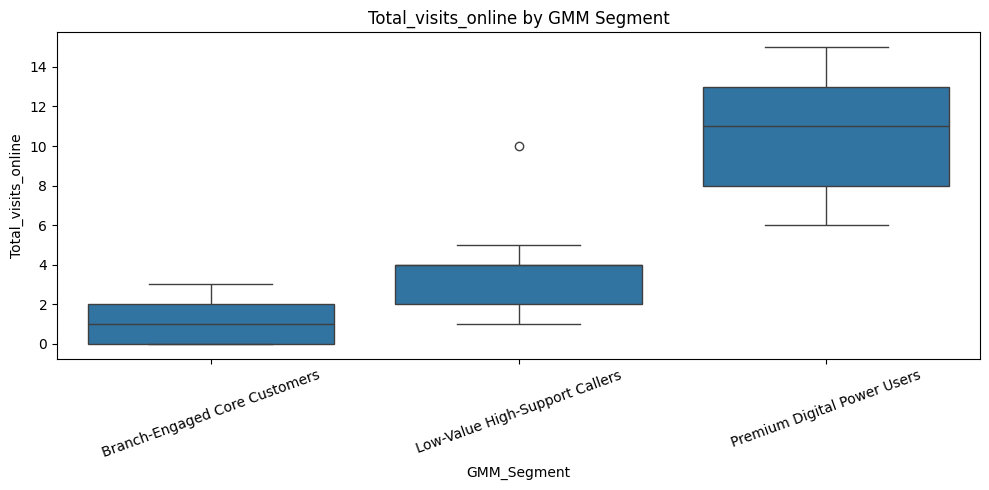

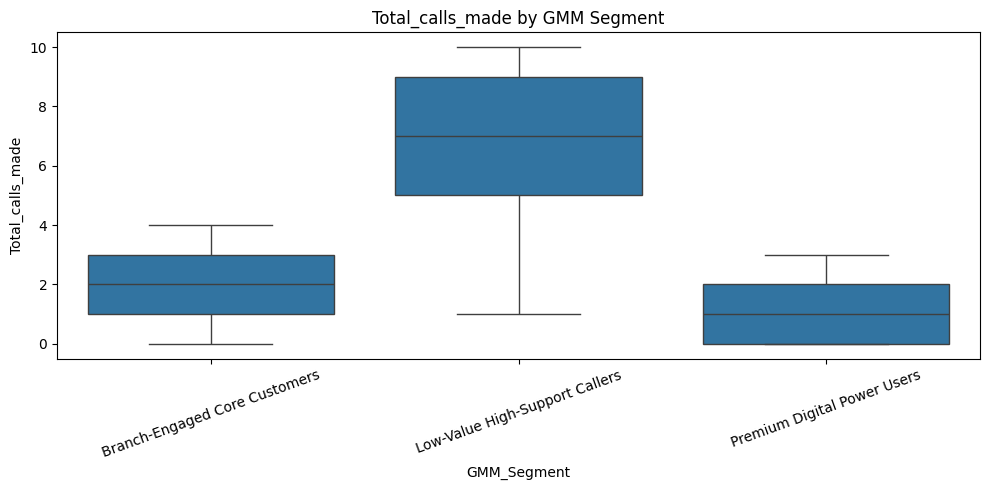

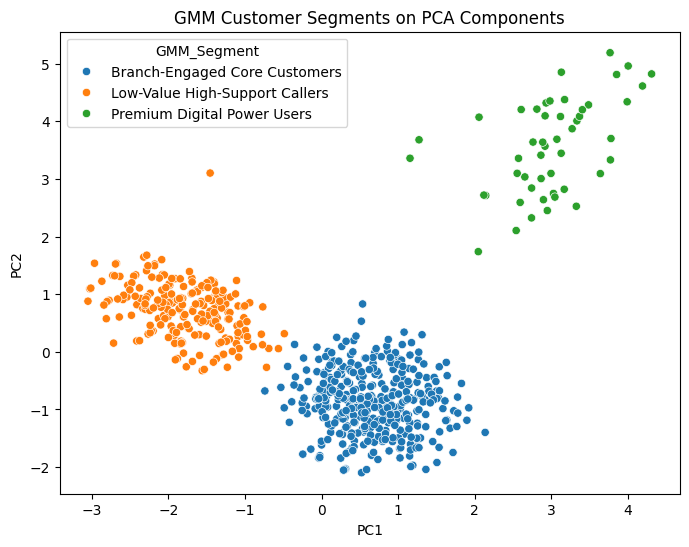

In [ ]:
gmm_profile = cluster_profile(df_clean, "GMM_Segment").sort_values("Avg_Credit_Limit")
display(gmm_profile)

for col in cluster_df.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df_clean, x="GMM_Segment", y=col)
    plt.title(f"{col} by GMM Segment")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pd.concat([pca_df[["PC1", "PC2"]], df_clean["GMM_Segment"]], axis=1),
                x="PC1", y="PC2", hue="GMM_Segment")
plt.title("GMM Customer Segments on PCA Components")
plt.show()

### K-Means vs. Gaussian Mixture Model

In [ ]:
# Compare K-Means and GMM segments
comparison_kmeans_gmm = pd.crosstab(df_clean["KMeans_Segment"], df_clean["GMM_Segment"])
display(comparison_kmeans_gmm)

print("K-Means silhouette:", silhouette_score(pca_df, df_clean["KMeans_Cluster"]))
print("GMM silhouette:", silhouette_score(pca_df, df_clean["GMM_Cluster"]))

K-Means silhouette: 0.6034498298128758
GMM silhouette: 0.6034498298128758


Comparing Clusters:

- K-Means and GMM both identify three meaningful customer groups.

- The strongest agreement is around the premium digital group because those customers are clearly separated by very high credit limits and high online visits.

- Differences may occur near the border between branch-engaged customers and high-support callers because some customers show mixed interaction behavior.

- K-Means is easier to explain to business stakeholders and gives a clean segmentation structure, so it is the preferred operational model.

## K-Medoids

- Apply the K-Medoids clustering algorithm on the pca components

In [ ]:
# K-Medoids clustering
# Try sklearn_extra first. If unavailable, use a simple PAM-style fallback.

try:
    from sklearn_extra.cluster import KMedoids
    kmedoids_final = KMedoids(n_clusters=3, random_state=42, metric="euclidean")
    df_clean["KMedoids_Cluster"] = kmedoids_final.fit_predict(pca_df)
except Exception as e:
    print("sklearn_extra is not available. Using fallback K-Medoids implementation.")

    X = pca_df.values
    k = 3

    # Initialize medoids using points nearest to K-Means centers
    centers = kmeans_final.cluster_centers_
    distances_to_centers = cdist(X, centers)
    medoid_indices = np.argmin(distances_to_centers, axis=0)
    medoid_indices = np.array(list(dict.fromkeys(medoid_indices)))

    # If duplicate medoids occurred, add farthest points until k medoids are selected
    while len(medoid_indices) < k:
        dist_to_selected = cdist(X, X[medoid_indices]).min(axis=1)
        next_idx = np.argmax(dist_to_selected)
        medoid_indices = np.append(medoid_indices, next_idx)

    for iteration in range(20):
        distances = cdist(X, X[medoid_indices])
        labels = np.argmin(distances, axis=1)
        new_medoids = medoid_indices.copy()

        for cluster in range(k):
            cluster_points = np.where(labels == cluster)[0]
            if len(cluster_points) == 0:
                continue
            intra_dist = cdist(X[cluster_points], X[cluster_points])
            new_medoids[cluster] = cluster_points[np.argmin(intra_dist.sum(axis=1))]

        if np.array_equal(new_medoids, medoid_indices):
            break
        medoid_indices = new_medoids

    distances = cdist(X, X[medoid_indices])
    df_clean["KMedoids_Cluster"] = np.argmin(distances, axis=1)

kmedoids_profile_temp = df_clean.groupby("KMedoids_Cluster")[cluster_df.columns].mean()
kmedoids_names = name_segments(kmedoids_profile_temp)
df_clean["KMedoids_Segment"] = df_clean["KMedoids_Cluster"].map(kmedoids_names)

display(kmedoids_profile_temp)
print(kmedoids_names)

sklearn_extra is not available. Using fallback K-Medoids implementation.


{0: 'Branch-Engaged Core Customers', 1: 'Premium Digital Power Users', 2: 'Low-Value High-Support Callers'}


#### Create cluster profiles using the summary statistics and box plots for each label

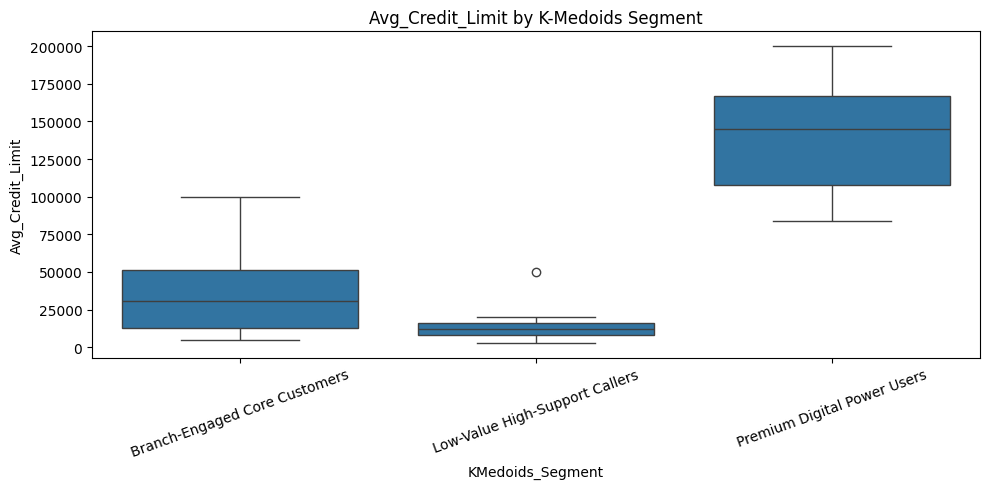

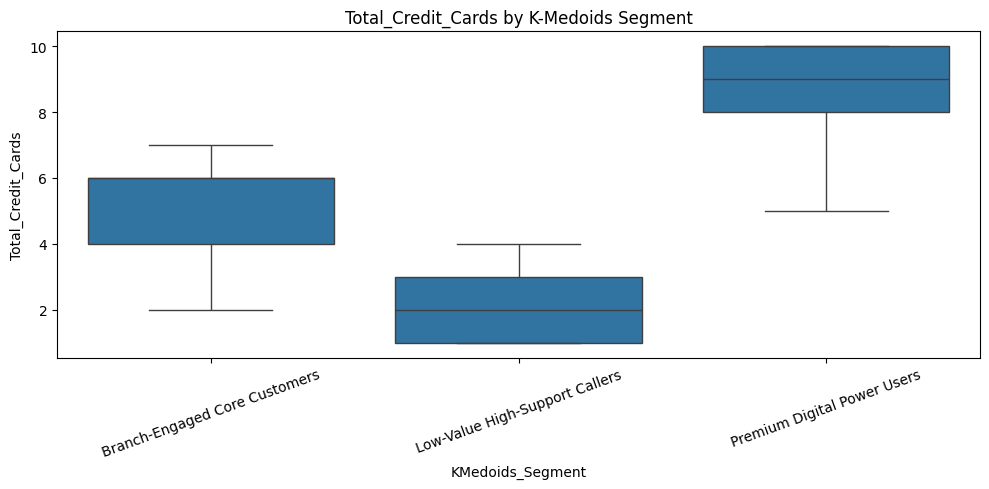

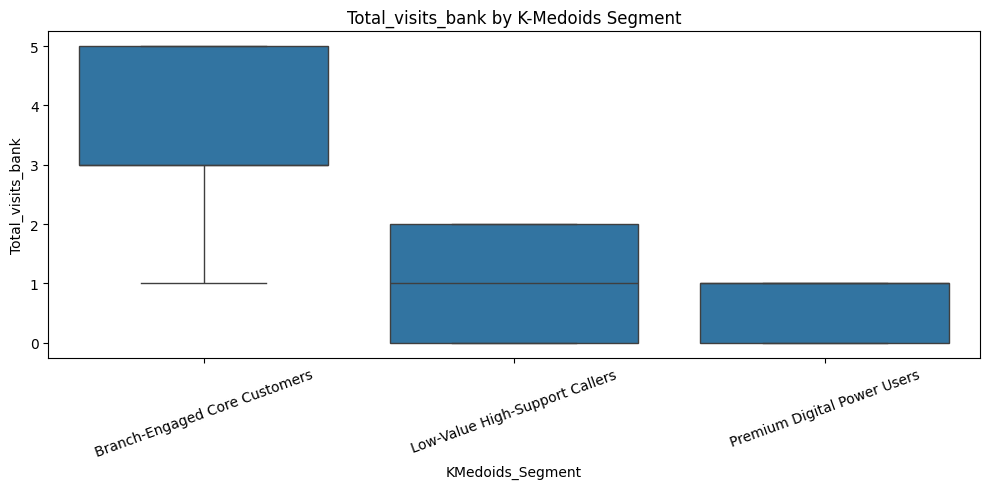

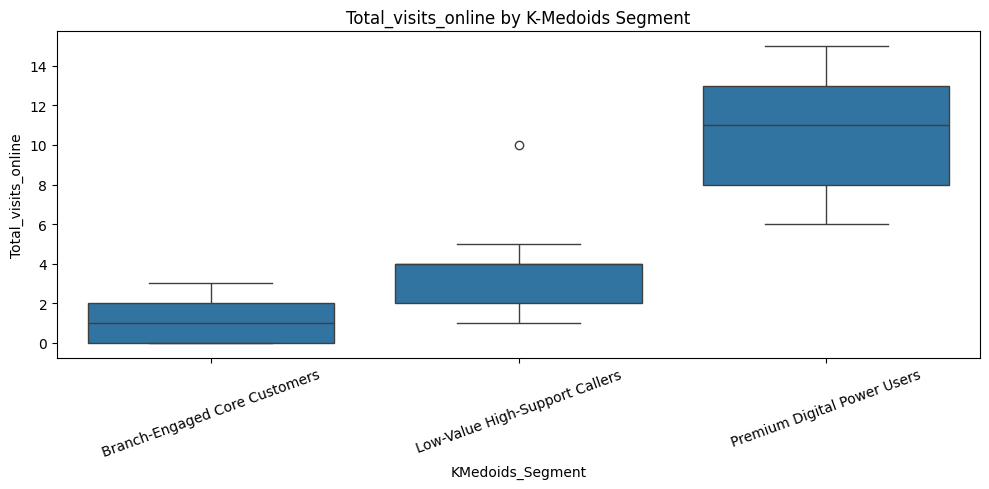

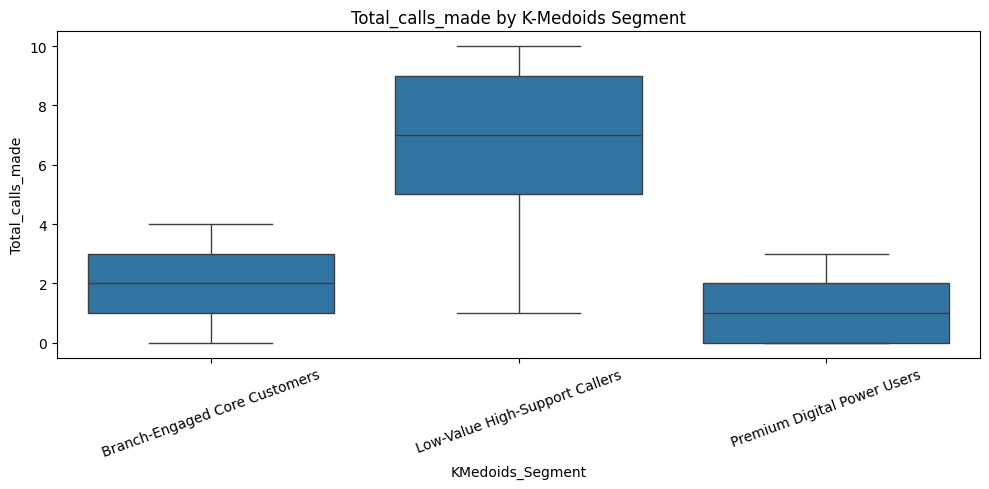

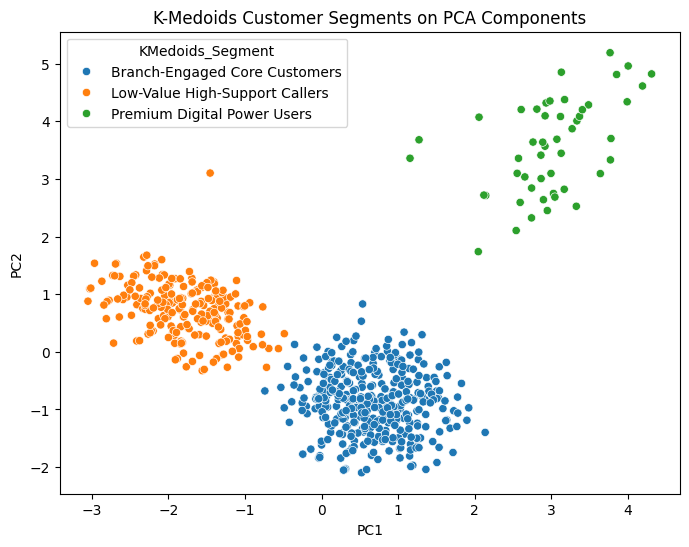

In [ ]:
kmedoids_profile = cluster_profile(df_clean, "KMedoids_Segment").sort_values("Avg_Credit_Limit")
display(kmedoids_profile)

for col in cluster_df.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df_clean, x="KMedoids_Segment", y=col)
    plt.title(f"{col} by K-Medoids Segment")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pd.concat([pca_df[["PC1", "PC2"]], df_clean["KMedoids_Segment"]], axis=1),
                x="PC1", y="PC2", hue="KMedoids_Segment")
plt.title("K-Medoids Customer Segments on PCA Components")
plt.show()

Cluster Profiles:

- K-Medoids produces the same overall business story as K-Means: a premium digital group, a branch-engaged core group, and a low-value high-support caller group.

- The medoid-based approach is useful because each cluster is represented by an actual customer-like observation rather than an average centroid.

- The profiles remain commercially interpretable, which supports the stability of the three-segment solution.

### K-Means vs. K-Medoids

In [ ]:
# Compare K-Means and K-Medoids
comparison_kmeans_kmedoids = pd.crosstab(df_clean["KMeans_Segment"], df_clean["KMedoids_Segment"])
display(comparison_kmeans_kmedoids)

print("K-Means silhouette:", silhouette_score(pca_df, df_clean["KMeans_Cluster"]))
print("K-Medoids silhouette:", silhouette_score(pca_df, df_clean["KMedoids_Cluster"]))

K-Means silhouette: 0.6034498298128758
K-Medoids silhouette: 0.6034498298128758


Comparing Clusters:

- K-Means and K-Medoids produce very similar segment interpretations.

- K-Means usually gives slightly stronger separation and is simpler to operationalize.

- K-Medoids is more robust to extreme values because cluster centers are actual observations, but K-Means is preferred here because the results are clean, stable, and easy to explain.

## Conclusions and Business Recommendations

## Conclusions and Business Recommendations

The analysis supports a three-segment customer strategy for AllLife Bank.

### 1. Branch-Engaged Core Customers

This is the largest group. These customers have moderate credit limits, multiple credit cards, and the highest branch visit behavior. They should be targeted through branch relationship managers, pre-qualified cross-sell offers, bundled financial products, and in-person card education.

### 2. Premium Digital Power Users

This is the smallest but highest-value group. These customers have very high credit limits, the most cards, and heavy online engagement. They should receive digital-first premium offers, higher-limit products, concierge service, rewards upgrades, and retention benefits.

### 3. Low-Value High-Support Callers

This group has the lowest credit limits, fewer credit cards, and the highest number of calls. The bank should avoid aggressive upsell at first and instead focus on digital education, proactive service alerts, simpler products, FAQ/self-service tools, and call deflection workflows.

### Final Recommendation

K-Means with 3 clusters is the recommended segmentation model because it provides strong separation, clear business meaning, and easy implementation. AllLife Bank should deploy these segment labels into its CRM, pilot segment-specific marketing campaigns, and track campaign response, service-cost reduction, retention, and credit-card utilization.